In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/ankushpanjiyar/latent-symmetry/pytorch/default/1/latent_classifier.pth
/kaggle/input/models/ankushpanjiyar/latent-symmetry/pytorch/default/1/symmetry_generator.pth
/kaggle/input/models/ankushpanjiyar/latent-symmetry/pytorch/default/1/vae_task3_model.pth


# Bonus Task: Rotation Invariant Network

## Objective

Using the symmetry generator discovered in Task 3, we construct a rotation-invariant classifier.

The goal is to ensure that the classifier prediction remains unchanged for rotated versions of the same image.

## Method

For a latent representation z, the symmetry generator produces a sequence of transformed latent vectors:

z₀ = z  
z₁ = z₀ + εg(z₀)  
z₂ = z₁ + εg(z₁)  
...  

Each of these latent vectors represents the same digit under a different rotation.

Predictions are obtained for all transformed latent vectors and averaged:

ψ_invariant(z) = mean( ψ(z_k) )

This produces a classifier that is invariant to rotations.

## Evaluation

Two models are compared:

• baseline classifier  
• rotation-invariant classifier

The invariant classifier should produce stable predictions across rotations.

## Visualization

Experiments include:

• prediction stability under rotation  
• latent orbit visualization  
• decoded symmetry flows

These results demonstrate that the learned symmetry can be used to construct rotation-invariant models.

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
# ============================================================
# Cell 2 — Load Rotated MNIST Dataset (digits 1 & 2)
# ============================================================

transform = transforms.ToTensor()

mnist = MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

images = []
labels = []

for img, label in mnist:
    if label in [1,2]:
        images.append(img)
        labels.append(label)

images = torch.stack(images)
labels = torch.tensor(labels)

angles = list(range(0,360,30))

rotated_images = []
rotated_labels = []

for img,label in zip(images,labels):

    for angle in angles:

        rotated = TF.rotate(img, angle)

        rotated_images.append(rotated)
        rotated_labels.append(label)

rotated_images = torch.stack(rotated_images)
rotated_labels = torch.tensor(rotated_labels)

print("Dataset shape:", rotated_images.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.58MB/s]


Dataset shape: torch.Size([26004, 1, 28, 28])


In [4]:
# ============================================================
# Cell 3 — Define Model Architectures
# ============================================================

latent_dim = 32


class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,4,stride=2,padding=1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(64*7*7,latent_dim)
        self.fc_logvar = nn.Linear(64*7*7,latent_dim)

    def forward(self,x):

        x = self.conv(x)
        x = x.view(x.size(0),-1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu,logvar


class Decoder(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(latent_dim,64*7*7)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,stride=2,padding=1),
            nn.Sigmoid()
        )

    def forward(self,z):
        x = self.fc(z)
        x = x.view(-1,64,7,7)
        return self.deconv(x)


class VAE(nn.Module):

    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self,mu,logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std


class LatentClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,2)
        )

    def forward(self,z):
        return self.net(z)


class SymmetryGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,latent_dim)
        )

    def forward(self,z):
        g = self.net(z)
        g = F.normalize(g,dim=1)
        return g

In [7]:
# ============================================================
# Cell 4 — Load Trained Models from Task 3
# ============================================================

vae = VAE().to(device)
vae.load_state_dict(torch.load("/kaggle/input/models/ankushpanjiyar/latent-symmetry/pytorch/default/1/vae_task3_model.pth", map_location=device))
classifier = LatentClassifier().to(device)
classifier.load_state_dict(torch.load("/kaggle/input/models/ankushpanjiyar/latent-symmetry/pytorch/default/1/latent_classifier.pth", map_location=device))
generator = SymmetryGenerator().to(device)
generator.load_state_dict(torch.load("/kaggle/input/models/ankushpanjiyar/latent-symmetry/pytorch/default/1/symmetry_generator.pth", map_location=device))
encoder = vae.encoder

encoder.eval()
classifier.eval()
generator.eval()

print("Models loaded successfully")

Models loaded successfully


In [8]:
# ============================================================
# Cell 5 — Baseline Latent Classifier (no invariance)
# ============================================================

test_dataset = TensorDataset(
    rotated_images,
    rotated_labels-1
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256
)

correct = 0
total = 0

with torch.no_grad():

    for x_batch,y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mu,_ = encoder(x_batch)
        logits = classifier(mu)
        preds = torch.argmax(logits,dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

baseline_acc = correct/total
print("Baseline accuracy:", baseline_acc)

Baseline accuracy: 0.5974465466851253


In [9]:
# ============================================================
# Cell 6 — Rotation Invariant Prediction using Symmetry Flow
# ============================================================

epsilon = 0.02
num_steps = 12

def invariant_logits(z):
    B = z.size(0)
    orbit = []
    z_k = z
    for _ in range(num_steps):
        orbit.append(z_k)
        g = generator(z_k)
        z_k = z_k + epsilon*g

    orbit = torch.cat(orbit,dim=0)
    logits = classifier(orbit)
    logits = logits.view(num_steps,B,-1)
    logits = logits.mean(dim=0)
    return logits

In [12]:
# ============================================================
# Cell 7 — Evaluate Rotation Invariant Network
# ============================================================

correct = 0
total = 0

with torch.no_grad():

    for x_batch,y_batch in tqdm(test_loader):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mu,_ = encoder(x_batch)
        logits = invariant_logits(mu)
        preds = torch.argmax(logits,dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

invariant_acc = correct/total
print("Invariant accuracy:", invariant_acc)

100%|██████████| 102/102 [00:02<00:00, 42.27it/s]

Invariant accuracy: 0.5972927241962775


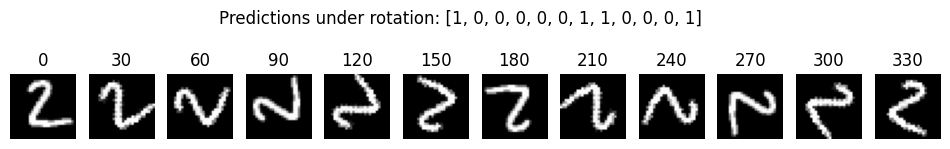

In [13]:
# ============================================================
# Cell 8 — Compare Predictions for Rotated Versions
# ============================================================

idx = 0
img = images[idx]
fig,ax = plt.subplots(1,12,figsize=(12,2))
predictions = []

with torch.no_grad():
    for i,angle in enumerate(angles):
        rotated = TF.rotate(img,angle).unsqueeze(0).to(device)
        mu,_ = encoder(rotated)
        logits = invariant_logits(mu)
        pred = torch.argmax(logits,dim=1).item()
        predictions.append(pred)
        ax[i].imshow(rotated.cpu()[0,0],cmap="gray")
        ax[i].set_title(f"{angle}")
        ax[i].axis("off")

plt.suptitle("Predictions under rotation: "+str(predictions))
plt.show()

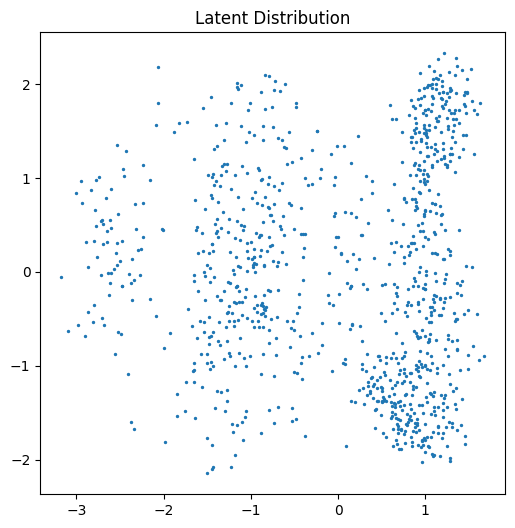

In [19]:
# ============================================================
# Cell 9 — Visualize Symmetry Orbit in Latent Space
# ============================================================

from sklearn.decomposition import PCA
with torch.no_grad():
    z = encoder(rotated_images[:1000].to(device))[0].cpu().numpy()
pca = PCA(n_components=2)
z_2d = pca.fit_transform(z)
plt.figure(figsize=(6,6))
plt.scatter(z_2d[:,0],z_2d[:,1],s=2)
plt.title("Latent Distribution")
plt.show()

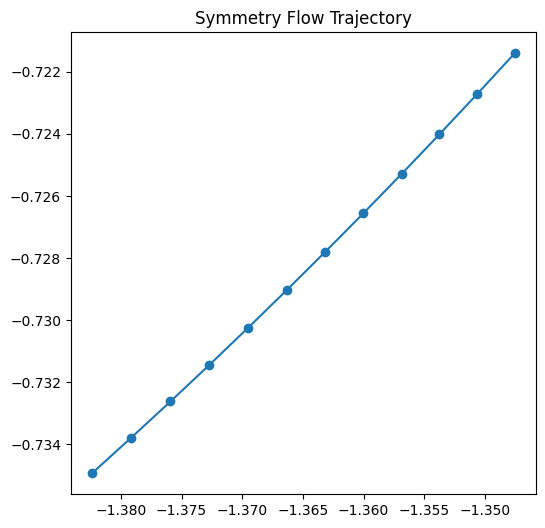

In [20]:
# ============================================================
# Cell 10 — Symmetry Flow Visualization
# ============================================================
with torch.no_grad():
    z = encoder(images[0].unsqueeze(0).to(device))[0]
trajectory = []
with torch.no_grad():
    for _ in range(12):
        trajectory.append(z.cpu().numpy()[0])
        g = generator(z)
        z = z + epsilon*g

trajectory = np.array(trajectory)
traj_2d = pca.transform(trajectory)
plt.figure(figsize=(6,6))
plt.plot(traj_2d[:,0],traj_2d[:,1],marker='o')
plt.title("Symmetry Flow Trajectory")
plt.show()

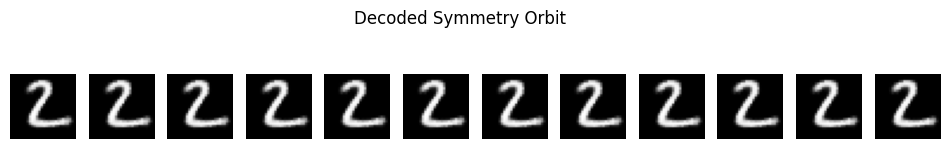

In [18]:
# ============================================================
# Cell 11 — Decode Symmetry Flow (visual proof of rotation)
# ============================================================

z = encoder(images[0].unsqueeze(0).to(device))[0]
sequence = []
with torch.no_grad():
    for _ in range(12):
        recon = vae.decoder(z)
        sequence.append(recon.cpu())
        g = generator(z)
        z = z + epsilon*g

plt.figure(figsize=(12,2))

for i in range(12):
    plt.subplot(1,12,i+1)
    plt.imshow(sequence[i][0,0],cmap="gray")
    plt.axis("off")

plt.suptitle("Decoded Symmetry Orbit")
plt.show()